In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.cloud import bigquery
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

client = bigquery.Client()

query_ej = f"""
SELECT *
FROM `{config['tables']['int_experiment_journey']}`
"""
query_df = f"""
SELECT *
FROM `{config['tables']['int_digital_footprints']}`
"""
query_cd = f"""
SELECT *
FROM `{config['tables']['int_client_dimension']}`
"""
query_jr = f"""
SELECT *
FROM `{config['tables']['int_journey_rank']}`
"""

df_cd = client.query(query_cd).to_dataframe()
df_jr = client.query(query_jr).to_dataframe()
df_ej = client.query(query_ej).to_dataframe()

/Users/zhiwen.mo/Desktop/ironhack/week5/vanguard-ab-test/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/zhiwen.mo/Desktop/ironhack/week5/vanguard-ab-test/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureW

In [5]:
df_jr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317235 entries, 0 to 317234
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   client_id        317235 non-null  Int64              
 1   variation        317235 non-null  object             
 2   visitor_id       317235 non-null  object             
 3   visit_id         317235 non-null  object             
 4   visit_seq        317235 non-null  Int64              
 5   process_step     317235 non-null  object             
 6   next_step        247788 non-null  object             
 7   date_time        317235 non-null  datetime64[us, UTC]
 8   next_time        247788 non-null  datetime64[us, UTC]
 9   duration_sec     247788 non-null  Int64              
 10  current_rank     317235 non-null  Int64              
 11  next_rank        247788 non-null  Int64              
 12  step_diff        247788 non-null  Int64              
 13 

In [14]:
df_jr = df_jr.sort_values(by=['client_id','visitor_id','visit_id','date_time'])

In [ ]:
#experiment variation distribution
display(df_jr.groupby('variation')['client_id'].nunique())
display(df_cd.groupby('variation')['client_id'].nunique())

variation
Control    23532
Test       26968
Name: client_id, dtype: int64

variation
Control    23532
NA         20109
Test       26968
Name: client_id, dtype: int64

In [49]:
display(df_jr.groupby('variation')['client_id'].nunique().pipe(lambda x: x / x.sum()))
display(df_cd[df_cd['variation']!= "NA"]['variation'].value_counts(normalize=True))

variation
Control    0.46598
Test       0.53402
Name: client_id, dtype: float64

variation
Test       0.53402
Control    0.46598
Name: proportion, dtype: float64

In [54]:
df_jr.head(10)

,client_id,variation,visitor_id,visit_id,visit_seq,process_step,next_step,date_time,next_time,duration_sec,current_rank,next_rank,step_diff,transition_type
124693,555,Test,402506806_56087378777,637149525_38041617439_716659,1,start,step_1,2017-04-15 12:57:56+00:00,2017-04-15 12:58:03+00:00,7,1,2,1,forward
189292,555,Test,402506806_56087378777,637149525_38041617439_716659,2,step_1,step_2,2017-04-15 12:58:03+00:00,2017-04-15 12:58:35+00:00,32,2,3,1,forward
243459,555,Test,402506806_56087378777,637149525_38041617439_716659,3,step_2,step_3,2017-04-15 12:58:35+00:00,2017-04-15 13:00:14+00:00,99,3,4,1,forward
288980,555,Test,402506806_56087378777,637149525_38041617439_716659,4,step_3,confirm,2017-04-15 13:00:14+00:00,2017-04-15 13:00:34+00:00,20,4,5,1,forward
18704,555,Test,402506806_56087378777,637149525_38041617439_716659,5,confirm,None,2017-04-15 13:00:34+00:00,NaT,<NA>,5,<NA>,<NA>,end
155827,647,Test,66758770_53988066587,40369564_40101682850_311847,1,start,step_1,2017-04-12 15:41:28+00:00,2017-04-12 15:41:35+00:00,7,1,2,1,forward
215338,647,Test,66758770_53988066587,40369564_40101682850_311847,2,step_1,step_2,2017-04-12 15:41:35+00:00,2017-04-12 15:41:53+00:00,18,2,3,1,forward
265550,647,Test,66758770_53988066587,40369564_40101682850_311847,3,step_2,step_3,2017-04-12 15:41:53+00:00,2017-04-12 15:45:02+00:00,189,3,4,1,forward
306724,647,Test,66758770_53988066587,40369564_40101682850_311847,4,step_3,confirm,2017-04-12 15:45:02+00:00,2017-04-12 15:47:45+00:00,163,4,5,1,forward
50527,647,Test,66758770_53988066587,40369564_40101682850_311847,5,confirm,None,2017-04-12 15:47:45+00:00,NaT,<NA>,5,<NA>,<NA>,end


## Performance Metrics

**Success Indicators**  
You have now been asked to discover what key performance indicators (KPIs) will determine the success of the new design? Use at least completion rate, time spent on each step and error rates. Add any KPIs you might find relevant.  

- Completion Rate: The proportion of users who reach the final 'confirm' step.
- Time Spent on Each Step: The average duration users spend on each step.
- Error Rates: If there's a step where users go back to a previous step, it may indicate confusion or an error. You should consider moving from a later step to an earlier one as an error.  

**Redesign Outcome**  
Based on the chosen KPIs, how does the new design's performance compare to the old one?

In [72]:
#Completion Rate: The proportion of users who reach the final 'confirm' step.
total_clients = df_jr['client_id'].nunique()

completed_clients = (
    df_jr.loc[df_jr['process_step'] == 'confirm', 'client_id']
      .nunique()
)

completion_rate = completed_clients / total_clients

clients_summary = (
    df_jr
    .groupby('variation')['client_id']
    .nunique()
)

completed_summary = (
    df_jr.loc[df_jr['process_step'] == 'confirm']
    .groupby('variation')['client_id']
    .nunique()
)

summary = pd.DataFrame({
    'total_clients': clients_summary,
    'completed_clients': completed_summary
})

summary['completion_rate'] = (
    summary['completed_clients']
    / summary['total_clients']
)

plot_df = summary.loc[
    ['Control', 'Test']
].reset_index()

summary.loc['Overall'] = [
    total_clients,
    completed_clients,
    completion_rate
]

summary['completion_rate'] = (
    summary['completion_rate']
    .map('{:.2%}'.format)
)


summary

,total_clients,completed_clients,completion_rate
variation,,,
Control,23532.0,15434.0,65.59%
Test,26968.0,18687.0,69.29%
Overall,50500.0,34121.0,67.57%


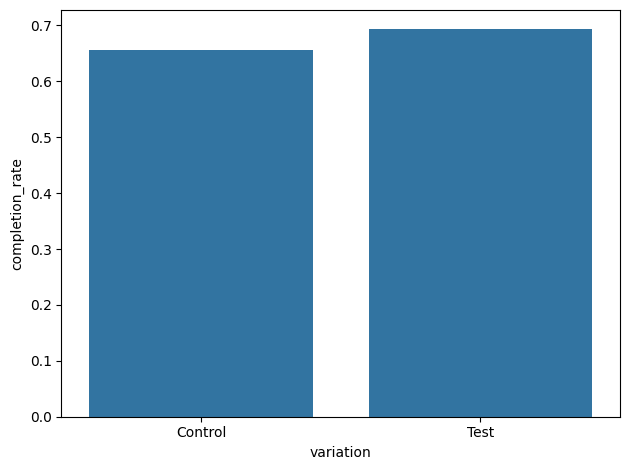

In [73]:
fig, ax = plt.subplots()
sns.barplot(
    data=plot_df,
    x='variation',
    y='completion_rate',
)
plt.tight_layout()
plt.show()

In [ ]:
"""
fig, ax = plt.subplots(2, 3, figsize=(10, 6))

sns.histplot(df_cd_clean['clnt_age'],bins=20,ax=ax[0,0])
sns.histplot(df['clnt_tenure_yr'],ax=ax[0,2],bins=20)
sns.countplot(x='gendr',data=df_cd_clean,ax=ax[0,1])
sns.barplot(
    x='gendr',
    y='bal',
    data=df_cd_clean,
    ax=ax[1,1]
)
sns.boxplot(x=df_cd_clean['clnt_age'],ax=ax[1,0])
sns.histplot(df['logons_6_mnth'],ax=ax[1,0])

plt.tight_layout()
plt.show()
"""

"\nfig, ax = plt.subplots(2, 3, figsize=(10, 6))\n\nsns.histplot(df_cd_clean['clnt_age'],bins=20,ax=ax[0,0])\nsns.histplot(df['clnt_tenure_yr'],ax=ax[0,2],bins=20)\nsns.countplot(x='gendr',data=df_cd_clean,ax=ax[0,1])\nsns.barplot(\n    x='gendr',\n    y='bal',\n    data=df_cd_clean,\n    ax=ax[1,1]\n)\nsns.boxplot(x=df_cd_clean['clnt_age'],ax=ax[1,0])\nsns.histplot(df['logons_6_mnth'],ax=ax[1,0])\n\nplt.tight_layout()\nplt.show()\n"

In [21]:
#Time Spent on Each Step
df_duration = df_jr.groupby(['variation','process_step'])['duration_sec'].mean().reset_index()
display(df_duration)

,variation,process_step,duration_sec
0,Control,confirm,168.727083
1,Control,start,66.826566
2,Control,step_1,50.468456
3,Control,step_2,92.00473
4,Control,step_3,137.135454
5,Test,confirm,243.690389
6,Test,start,61.471494
7,Test,step_1,60.67543
8,Test,step_2,88.849153
9,Test,step_3,129.636784


<Axes: xlabel='process_step', ylabel='duration_sec'>

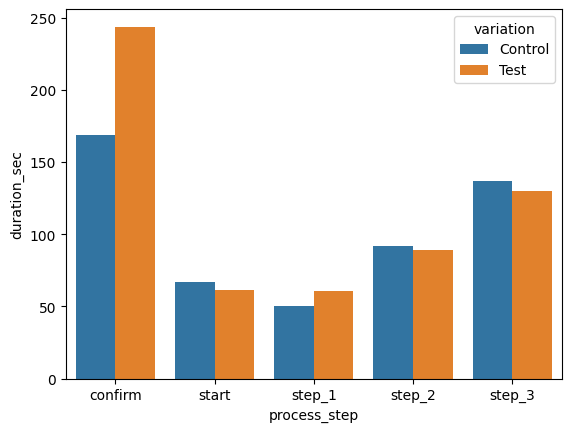

In [22]:
sns.barplot(
    data=df_duration,
    x='process_step',
    y='duration_sec',
    hue='variation'
)

In [ ]:
df_duration_median = df_jr.groupby(['variation','process_step'])['duration_sec'].median()

variation  process_step
Control    confirm         46.0
           start           20.0
           step_1          20.0
           step_2          64.0
           step_3          72.0
Test       confirm         93.0
           start           14.0
           step_1          27.0
           step_2          61.0
           step_3          58.0
Name: duration_sec, dtype: Float64

<Axes: xlabel='process_step', ylabel='duration_sec'>

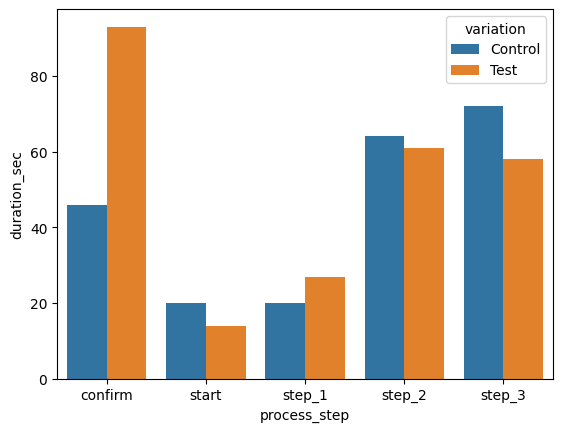

In [19]:
median_duration = (
    df_jr.groupby(['variation','process_step'])['duration_sec']
    .median()
    .reset_index()
)

sns.barplot(
    data=median_duration,
    x='process_step',
    y='duration_sec',
    hue='variation'
)

In [6]:
df_jr.groupby('visit_id')['process_step'] \
     .apply(lambda x: (x=='confirm').sum()) \
     .describe()

count    69205.000000
mean         0.620418
std          0.681654
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         11.000000
Name: process_step, dtype: float64

In [13]:
df_jr[(df_jr['process_step']=="confirm") & df_jr['next_step'].notna()]

,client_id,variation,visitor_id,visit_id,visit_seq,process_step,next_step,date_time,next_time,duration_sec,current_rank,next_rank,step_diff,transition_type
69493,2299456,Control,511021068_36227220938,178690613_43229450872_969355,5,confirm,start,2017-03-29 13:09:09+00:00,2017-03-29 13:11:23+00:00,134,5,1,-4,backward
69536,4008625,Control,473601656_77507598654,294078361_1002721045_879215,6,confirm,start,2017-03-15 19:59:20+00:00,2017-03-15 20:00:20+00:00,60,5,1,-4,backward
69643,6575566,Control,143038172_18564060779,484631561_42380606121_604661,6,confirm,start,2017-04-16 02:38:16+00:00,2017-04-16 02:41:35+00:00,199,5,1,-4,backward
69662,7116423,Test,939712117_71587565939,200827274_88708804706_343871,15,confirm,start,2017-04-08 15:47:57+00:00,2017-04-08 15:49:25+00:00,88,5,1,-4,backward
69703,8101488,Control,51773182_49136125368,247317730_29703676495_963267,5,confirm,start,2017-04-12 22:23:14+00:00,2017-04-12 22:29:58+00:00,404,5,1,-4,backward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317157,8103252,Test,315017123_36761437678,522753409_63363902297_167735,7,confirm,confirm,2017-04-18 17:52:37+00:00,2017-04-18 17:54:43+00:00,126,5,5,0,same_step
317159,8154471,Test,874992995_40976412413,78558295_42422218659_892202,5,confirm,confirm,2017-04-04 15:03:57+00:00,2017-04-04 15:08:02+00:00,245,5,5,0,same_step
317186,8794692,Test,779772470_41125876440,455025324_29872718466_265323,1,confirm,confirm,2017-04-25 20:59:59+00:00,2017-04-25 21:00:39+00:00,40,5,5,0,same_step
317216,9575576,Test,184571090_72167819648,448862462_59031851820_903973,7,confirm,confirm,2017-03-29 13:37:40+00:00,2017-03-29 13:38:05+00:00,25,5,5,0,same_step


## Hypothesis Testing

As part of your analysis, you'll conduct hypothesis testing to make data-driven conclusions about the effectiveness of the redesign. See the full details below:

**Completion Rate**   
Given the data and KPIs you have explored discussed, one interesting hypothesis to test is related to the completion rate between the Test and Control groups. Since the new design (Test group) had a higher completion rate compared to the old design (Control group), you are required to confirm if this difference is statistically significant.  
Make sure to define the proper null and an alternative hypothesis to test it. Use the provided data to test these hypotheses, and determine if you can reject the null hypothesis in favor of the alternative. Make sure to consider the significance level, p-value, the statistical test prerequisites, and other relevant statistical measures in your analysis.

**Completion Rate with a Cost-Effectiveness Threshold**   
The introduction of a new UI design comes with its associated costs: design, development, testing, potential training for staff, and possible short-term disruptions or adjustments for users. To justify these costs, Vanguard has determined that any new design should lead to a minimum increase in the completion rate to be deemed cost-effective.  
Threshold: Vanguard has set this minimum increase in completion rate at 5%. This is the rate at which the projected benefits, in terms of increased user engagement and potential revenue, are estimated to outweigh the costs of the new design.  
You are required to carry out another analysis, ensuring that the observed increase in completion rate from the A/B test meets or exceeds this 5% threshold. If the new design doesn't lead to at least this level of improvement, it may not be justifiable from a cost perspective, regardless of its statistical significance.

In [ ]:
#completion rate
#H0 : no discrepancy of completion rate between test and control grouup
#H1 : test group has higher completion rate

In [79]:
test_rate = plot_df.loc[
    plot_df['variation'] == 'Test',
    'completion_rate'
].iloc[0]

control_rate = plot_df.loc[
    plot_df['variation'] == 'Control',
    'completion_rate'
].iloc[0]

absolute_lift = (
    test_rate - control_rate
)
relative_lift = (
    test_rate - control_rate
) / control_rate

print(f"Test completion rate: {test_rate:.2%}")
print(f"Control completion rate: {control_rate:.2%}")

print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.2%}")

Test completion rate: 69.29%
Control completion rate: 65.59%
Absolute lift: 3.71%
Relative lift: 5.65%


In [81]:
from statsmodels.stats.proportion import proportions_ztest

In [89]:
success = [18687, 15434]
nobs = [26968, 23532]

z_stat, p_value = proportions_ztest(
    count=success,
    nobs=nobs,
    alternative='larger'
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 8.8745141890702
P-value: 3.5119666237907166e-19
